In [1]:
# LangChain/LLama is framework to build RAGs

In [1]:
import torch

## 1.  document/ text processing and embedding creation

Ingredients:
* PDF documenrs of choice
* Embedding model of choice 



In [2]:
import os
import requests

pdf_file_name="human-nutrition-text.pdf"
pdf_path =f"Documents/{pdf_file_name}"

if not os.path.exists(pdf_path):
    print(f"file doesnt exist, downloading...")
    url="https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"

    response= requests.get(url)

    if(response.status_code==200):
        with open(pdf_path, "wb") as file:
            file.write(response.content)
        print(f"the file has been downloaded and saved as ({pdf_file_name})")
    else:
        print("Failed to download")
else:
    print("file exists")



print(pdf_path)

file exists
Documents/human-nutrition-text.pdf


In [3]:
# opening the pdf
import fitz
from tqdm.auto import tqdm

def text_formatter(text: str) -> str:
    """ performs minor formatting on text"""
    cleaned_text= text.replace("\n"," ").strip()

    return cleaned_text

def open_and_read_pdf(pdf_path: str) -> list[dict]:
    doc = fitz.open(pdf_path)
    pages_and_text=[]
    for page_number, page in tqdm(enumerate(doc)):
        text=page.get_text()
        text= text_formatter(text=text)
        pages_and_text.append({"page_number": page_number-41, 
                               "page_char_count":len(text),
                               "page_word_count": len(text.split(" ")),
                                "page_sentence_count":len(text.split(". ")),
                                "page_token_count": len(text)/4,
                                "text":text
                                })
    return pages_and_text

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]




0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count': 1,
  'page_token_count': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': -40,
  'page_char_count': 0,
  'page_word_count': 1,
  'page_sentence_count': 1,
  'page_token_count': 0.0,
  'text': ''}]

In [4]:
import random
random.sample(pages_and_texts, 3)

[{'page_number': 717,
  'page_char_count': 127,
  'page_word_count': 16,
  'page_sentence_count': 1,
  'page_token_count': 31.75,
  'text': 'view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=412  Understanding Dietary Reference Intakes  |  717'},
 {'page_number': 746,
  'page_char_count': 767,
  'page_word_count': 144,
  'page_sentence_count': 6,
  'page_token_count': 191.75,
  'text': 'Image by  Allison  Calabrese /  CC BY 4.0  Building a Healthy Plate: Choose  Nutrient-Dense Foods  Click on the different food groups listed to view their food gallery:  • Fruits  • Grains  • Dairy  • Vegetables  • Protein  Planning a healthy diet using the MyPlate approach is not difficult.  According to the icon, half of your plate should have fruits and  vegetables, one-quarter should have whole grains, and one-quarter  should have protein. Dairy products should be low-fat or non-fat.  The ideal diet gives you the most nutrients within the fewest  calories. This means choosin

In [5]:
import pandas as pd
df=pd.DataFrame(pages_and_texts)
df.head(5)

,page_number,page_char_count,page_word_count,page_sentence_count,page_token_count,text
0,-41,29,4,1,7.25,Human Nutrition: 2020 Edition
1,-40,0,1,1,0.00,
2,-39,320,54,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,-38,212,32,1,53.00,Human Nutrition: 2020 Edition by University of...
4,-37,797,145,2,199.25,Contents Preface University of Hawai‘i at Mā...


In [6]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00
std,348.86,560.38,95.76,6.19,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,4.00,190.50
50%,562.50,1231.50,214.50,10.00,307.88
75%,864.25,1603.50,271.00,14.00,400.88
max,1166.00,2308.00,429.00,32.00,577.00


In [7]:
# LLM context window: the number of tokens LLM can accept as inputs
# splitting pages into sentences

from spacy.lang.en import English
nlp = English()
nlp.add_pipe("sentencizer")

doc = nlp ("This is a sentence. This is a sentence. I like elephants")
list(doc.sents)


[This is a sentence., This is a sentence., I like elephants]

In [8]:
for item in tqdm(pages_and_texts):
    item["sentences"]= list(nlp(item["text"]).sents)
    item["sentences"]=[str(sentence) for sentence in item["sentences"]]
    item["page_sentence_count_spacy"]=len(item["sentences"])


  0%|          | 0/1208 [00:00<?, ?it/s]

In [9]:
random.sample(pages_and_texts,1)

[{'page_number': 641,
  'page_char_count': 1046,
  'page_word_count': 177,
  'page_sentence_count': 10,
  'page_token_count': 261.5,
  'text': 'cellular energy molecule, ATP, magnesium is required. More than  three hundred enzymatic reactions require magnesium. Magnesium  plays a role in the synthesis of DNA and RNA, carbohydrates, and  lipids, and is essential for nerve conduction and muscle contraction.  Another health benefit of magnesium is that it may decrease blood  pressure.  Many Americans do not get the recommended intake of  magnesium from their diets. Some observational studies suggest  mild magnesium deficiency is linked to increased risk for  cardiovascular disease. Signs and symptoms of severe magnesium  deficiency may include tremor, muscle spasms, loss of appetite, and  nausea.  Dietary Reference Intakes for Magnesium  The RDAs for magnesium for adults between ages nineteen and  thirty are 400 milligrams per day for males and 310 milligrams per  day for females. For adu

In [10]:
df=pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count,page_token_count,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,10.32
std,348.86,560.38,95.76,6.19,140.10,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,5.00
50%,562.50,1231.50,214.50,10.00,307.88,10.00
75%,864.25,1603.50,271.00,14.00,400.88,15.00
max,1166.00,2308.00,429.00,32.00,577.00,28.00


In [11]:
# chunking: process of splitting large texts into smaller ones
# there are frameworks like langChain

num_sentence_chunk_size=10

# [20] -> [10,10], [35] -> [10,10,10,5]

def split_list(input_list: list[str], slice_size: int = num_sentence_chunk_size) -> list[list[str]]:
    return [input_list[i:i+slice_size] for i in range(0,len(input_list), slice_size)]

test_list=list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [12]:
for item in tqdm(pages_and_texts):
    item["sentence_chunks"]=split_list(input_list=item["sentences"], slice_size=num_sentence_chunk_size)
    item["num_chunks"]= len(item["sentence_chunks"])


  0%|          | 0/1208 [00:00<?, ?it/s]

In [13]:
random.sample(pages_and_texts,1)

[{'page_number': 588,
  'page_char_count': 590,
  'page_word_count': 127,
  'page_sentence_count': 11,
  'page_token_count': 147.5,
  'text': 'Food  Serving Choline (mg) Percent Daily Value  Egg  1 large  147  27  Soybeans  ½ cup  107  19  Chicken breast  3 oz.  72  13  Mushrooms, shiitake ½ c.  58  11  Potatoes  1 large  57  10  Kidney beans  ½ c.  45  8  Peanuts  ¼ c.  24  4  Brown rice  1 c.  19  3  Fact Sheet for Health Professionals: Choline. National Institute of  Health, Office of Dietary Supplements. https://ods.od.nih.gov/ factsheets/Choline-HealthProfessional/. Updated January 25, 2017.  Accessed October 28, 2017.  Summary of Water-Soluble Vitamins  Table 9.31 Water-Soluble vitamins  588  |  Water-Soluble Vitamins',
  'sentences': ['Food  Serving Choline (mg) Percent Daily Value  Egg  1 large  147  27  Soybeans  ½ cup  107  19  Chicken breast  3 oz.',
   ' 72  13  Mushrooms, shiitake ½ c.  58  11  Potatoes  1 large  57  10  Kidney beans  ½ c.  45  8  Peanuts  ¼ c.  24  4  Bro

In [14]:
df= pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,198.30,9.97,287.00,10.32,1.53
std,348.86,560.38,95.76,6.19,140.10,6.30,0.64
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,4.00,190.50,5.00,1.00
50%,562.50,1231.50,214.50,10.00,307.88,10.00,1.00
75%,864.25,1603.50,271.00,14.00,400.88,15.00,2.00
max,1166.00,2308.00,429.00,32.00,577.00,28.00,3.00


In [15]:
# we embed each chunk of sentences into numerical embeddings

import re
pages_and_chunks =[]
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict ={}
        chunk_dict["page_number"]=item["page_number"]

        # join the sentences together into a paragrapgh like structure 
        joined_sentence_chunk ="".join(sentence_chunk).replace("  ", " ").strip()

        # .A -> . A
        joined_sentence_chunk =re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)

        chunk_dict["sentence_chunk"] = joined_sentence_chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"]=len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"]= len(joined_sentence_chunk)/4
        pages_and_chunks.append(chunk_dict)
    
len(pages_and_chunks)


  0%|          | 0/1208 [00:00<?, ?it/s]

1843

In [16]:
df= pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,734.44,112.33,183.61
std,347.79,447.54,71.22,111.89
min,-41.00,12.00,3.00,3.00
25%,280.50,315.00,44.00,78.75
50%,586.00,746.00,114.00,186.50
75%,890.00,1118.50,173.00,279.62
max,1166.00,1831.00,297.00,457.75


In [17]:
df.sample(5)

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
1132,736,Image by FDA/ Portion Distortion particularly ...,1103,170,275.75
1011,648,view it online here: http://pressbooks.oer.haw...,278,35,69.50
53,11,Vitamins Major Functions Water-soluble Thiamin...,1432,203,358.00
578,353,"Thus, it is important to learn to reduce the i...",661,120,165.25
760,478,"Accessed September 22, 2017. 478 | Weight Mana...",52,8,13.00


In [18]:
# short chunks may not be useful
min_token_length=30
for row in df[df["chunk_token_count"]<=min_token_length].sample(5).iterrows():
    print(f"chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}")


chunk token count: 24.75 | Text: Free radical reactions can continue unchecked unless stopped by a defense mechanism. The Atom | 461
chunk token count: 9.0 | Text: 1088 | Nutrition, Health and Disease
chunk token count: 24.0 | Text: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=485 930 | Older Adulthood: The Golden Years
chunk token count: 16.0 | Text: Accessed January 20, 2018. 1032 | The Effect of New Technologies
chunk token count: 26.25 | Text: Updated November 6, 2015. Accessed April 15, 2018. 1122 | Undernutrition, Overnutrition, and Malnutrition


In [19]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient='records')
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

In [20]:
# emnedding our text chunks
# while humans understand text, machines understand numbers
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device ='cpu')

# create a list of sentences
sentences = ["The Sentence transformer library provides an easy way to create embeddings.",
             "Sentences can be embedded one by one or in a list",
             "I like horses"]

embeddings = embedding_model.encode(sentences)
embeddings_dict= dict(zip(sentences, embeddings))

# see the embedings
for sentence, embedding in embeddings_dict.items():
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding}")
    print("")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sentence: The Sentence transformer library provides an easy way to create embeddings.
Embedding: [-3.44286263e-02  2.95328666e-02 -2.33643074e-02  5.57257906e-02
 -2.19098348e-02 -6.47054659e-03  1.02848597e-02 -6.57804087e-02
  2.29718499e-02 -2.61120573e-02  3.80421020e-02  5.61403222e-02
 -3.68746892e-02  1.52787818e-02  4.37021181e-02 -5.19723110e-02
  4.89479601e-02  3.58108757e-03 -1.29750986e-02  3.54382209e-03
  4.23262380e-02  3.52606401e-02  2.49402896e-02  2.99177002e-02
 -1.99382324e-02 -2.39751879e-02 -3.33375786e-03 -4.30450514e-02
  5.72014414e-02 -1.32517684e-02 -3.54478508e-02 -1.13936532e-02
  5.55562302e-02  3.61099304e-03  8.88526813e-07  1.14027048e-02
 -3.82229686e-02 -2.43545859e-03  1.51314139e-02 -1.32668923e-04
  5.00659496e-02 -5.50876707e-02  1.73445065e-02  5.00959717e-02
 -3.75959650e-02 -1.04463138e-02  5.08321859e-02  1.24861319e-02
  8.67377296e-02  4.64142673e-02 -2.10689977e-02 -3.90251130e-02
  1.99693325e-03 -1.42345615e-02 -1.86794642e-02  2.826694

In [21]:
embeddings[0].shape

(768,)

In [22]:
embedding= embedding_model.encode("My Favourite animal is the cow!")
embedding

array([-1.45473918e-02,  7.66726285e-02, -2.85871997e-02, -3.31283063e-02,
        3.65209803e-02,  4.78570014e-02, -7.08107650e-02,  1.62834190e-02,
        1.93443540e-02, -2.80482173e-02, -2.91747320e-02,  5.11309281e-02,
       -3.28719839e-02, -8.98756925e-03, -1.03672454e-02, -3.15488316e-02,
        4.22784053e-02, -9.13287513e-03, -1.94017068e-02,  4.35689352e-02,
       -2.31997985e-02,  4.29883078e-02, -1.72393192e-02, -2.01372243e-02,
       -3.13573815e-02,  8.08165222e-03, -2.06724945e-02, -2.27869786e-02,
        2.44812649e-02,  1.71968266e-02, -6.26673326e-02, -7.54797608e-02,
        3.57421935e-02, -5.46565000e-03,  1.24730320e-06, -7.63201574e-03,
       -3.53222042e-02,  1.91326980e-02,  3.99045758e-02,  2.11734721e-03,
        1.64565779e-02,  9.84057039e-03, -1.80700719e-02,  9.33836307e-03,
        3.23482975e-02,  5.84785305e-02,  4.23186868e-02,  1.62090976e-02,
       -9.14910883e-02,  1.82305686e-02, -5.25730476e-03, -7.81022012e-03,
       -3.47643718e-02, -

In [23]:

embedding_model.to("cpu")

# using nvidia GPU
# embedding_model.to("cuda")


for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"]=embedding_model.encode(item["sentence_chunk"])


  0%|          | 0/1680 [00:00<?, ?it/s]

In [24]:
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]
text_chunks[419]

'often. • Calm your “sweet tooth” by eating fruits, such as berries or an apple. • Replace sugary soft drinks with seltzer water, tea, or a small amount of 100 percent fruit juice added to water or soda water. The Food Industry: Functional Attributes of Carbohydrates and the Use of Sugar Substitutes In the food industry, both fast-releasing and slow-releasing carbohydrates are utilized to give foods a wide spectrum of functional attributes, including increased sweetness, viscosity, bulk, coating ability, solubility, consistency, texture, body, and browning capacity. The differences in chemical structure between the different carbohydrates confer their varied functional uses in foods. Starches, gums, and pectins are used as thickening agents in making jam, cakes, cookies, noodles, canned products, imitation cheeses, and a variety of other foods. Molecular gastronomists use slow- releasing carbohydrates, such as alginate, to give shape and texture to their fascinating food creations. Add

In [25]:
len(text_chunks)

1680

In [26]:
# embedding chunks in batch size
text_chunk_embeddings = embedding_model.encode(text_chunks, batch_size=32, convert_to_tensor=True)
text_chunk_embeddings

tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]])

In [27]:
# save embeddings to file
text_chunks_and_embeddings_df= pd.DataFrame( pages_and_chunks_over_min_token_len)
embeddings_df_save_path= "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [28]:
# #import saved file and view path
# text_chunks_and_embeddings_df_load= pd.read_csv(embeddings_df_save_path)
# text_chunks_and_embeddings_df_load.head(5)

In [29]:
# RAG goal: retrive relavant passages based on the query and use those passages to augment an input to an LLm so it can generate an output based on that relavant passages
# comparing embeddings is known as similarity search, vector search, sementic search
# if i search for "macronutrients functions" I should get relevant passages to that text but may not contain the words "macronutrient fucntions"

In [30]:
import random
import torch
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# importing embeddings
text_chunks_and_embeddings_df= pd.read_csv(embeddings_df_save_path)

#convert embedding column to np.array
text_chunks_and_embeddings_df['embedding']=text_chunks_and_embeddings_df['embedding'].apply(lambda x : np.fromstring(x.strip("[]"), sep=" "))

# convert embeddings into torch sensor
embeddings=torch.tensor(np.stack(text_chunks_and_embeddings_df['embedding'],axis=0), dtype=torch.float32)

#convert texts and embedding df to  list of dicts
pages_and_chunks= text_chunks_and_embeddings_df.to_dict(orient='records')

text_chunks_and_embeddings_df.head(5)

Device: cpu


,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,"[0.0674242601, 0.0902280584, -0.00509548606, -..."
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,"[0.0552156493, 0.059213791, -0.0166167803, -0...."
2,-37,Contents Preface University of Hawai‘i at Māno...,766,114,191.50,"[0.0279801451, 0.0339813605, -0.0206427146, 0...."
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,142,235.25,"[0.0682567134, 0.0381274335, -0.00846858136, -..."
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,"[0.033026401, -0.00849776901, 0.00957155507, -..."


In [31]:
embeddings.shape

torch.Size([1680, 768])

In [32]:
# create model

embedding_model=SentenceTransformer(model_name_or_path="all-mpnet-base-v2", device = device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [33]:
# semantice search
# 1. Define query
# 2. Turn the query into embeding
# 3. perform dot product or cosine similarity function betweeen the text embeddings and the query embedding
# 4. sort the results from 3 in descending


In [34]:
# define the query
query = "macronutrients functions"
print(f"query: {query}")

# Embed thr query woth same model
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# get the cosine similarity"
from time import perf_counter as timer
from sentence_transformers import util

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b= embeddings)[0]
end_time=timer()
print(f"time taken to get scores on {len(embeddings)} embeddings : {end_time-start_time:.5f} seconds.")

top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

query: macronutrients functions
time taken to get scores on 1680 embeddings : 0.00169 seconds.


torch.return_types.topk(
values=tensor([0.6926, 0.6738, 0.6646, 0.6536, 0.6473]),
indices=tensor([42, 47, 41, 51, 46]))

In [35]:
pages_and_chunks[42]['sentence_chunk']

'Macronutrients Nutrients that are needed in large amounts are called macronutrients. There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemical energy is converted into cellular energy that is then utilized to perform work, allowing our bodies to conduct their basic functions. A unit of measurement of food energy is the calorie. On nutrition food labels the amount given for “calories” is actually equivalent to each calorie multiplied by one thousand. A kilocalorie (one thousand calories, denoted with a small “c”) is synonymous with the “Calorie” (with a capital “C”) on nutrition food labels. Water is also a macronutrient in the sense that you require a large amount of it, but unlike the other macronutrients, it does not yield calories. Carbohydrates Carbohydrates are molecules composed of carbon, hydrogen, and oxygen.'

In [36]:
# for semantic search we need to calculate dot product across all the embeddings, imagine if we have 100M embedings, its not effcient
# we use a indexing technique using faiss, it provides approximate nearest neghbour search


In [37]:
import textwrap
def print_wrapped(text, wrap_length=80):
    wrapped_text=textwrap.fill(text, wrap_length)
    print(wrapped_text)

    

In [38]:
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"score: {score:.4f}")
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    print(f"page number: ({pages_and_chunks[idx]["page_number"]})")
    print("\n")
    
    

score: 0.6926
Text:
Macronutrients Nutrients that are needed in large amounts are called
macronutrients. There are three classes of macronutrients: carbohydrates,
lipids, and proteins. These can be metabolically processed into cellular energy.
The energy from macronutrients comes from their chemical bonds. This chemical
energy is converted into cellular energy that is then utilized to perform work,
allowing our bodies to conduct their basic functions. A unit of measurement of
food energy is the calorie. On nutrition food labels the amount given for
“calories” is actually equivalent to each calorie multiplied by one thousand. A
kilocalorie (one thousand calories, denoted with a small “c”) is synonymous with
the “Calorie” (with a capital “C”) on nutrition food labels. Water is also a
macronutrient in the sense that you require a large amount of it, but unlike the
other macronutrients, it does not yield calories. Carbohydrates Carbohydrates
are molecules composed of carbon, hydrogen, and 

In [39]:
# Reraking models: we can improve the order of the results using a reranking models


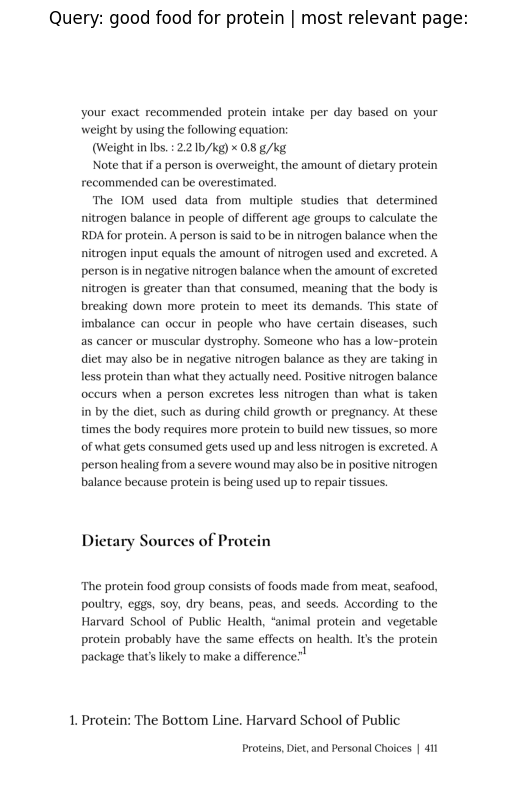

In [40]:
import fitz
import matplotlib.pyplot as plt

query= "good food for protein"
doc = fitz.open(pdf_path)
page = doc.load_page(411 + 41)
img = page.get_pixmap(dpi=300)
#img.save("output_filename.png")
doc.close()

# convert the pixmap to numpy array
img_array = np.frombuffer(img.samples_mv, dtype=np.uint8).reshape((img.h, img.w, img.n))

# display the image using matplotlib

plt.figure(figsize= (13,10))
plt.imshow(img_array)
plt.title(f"Query: {query} | most relevant page:")
plt.axis("off")
plt.show()


In [96]:
# similarity measures:
# 2 most common similarity measures between vectors are dot product and cosine similarity
# in essennce , closer vectors  will have higher scores, farther away vectors will have lower scores
# vector have : magnitude & direction


In [41]:
def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)
    
def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)
    norm_vector1=torch.sqrt(torch.sum(vector1**2))
    norm_vector2= torch.sqrt(torch.sum(vector2**2))
    return dot_product/( norm_vector1 * norm_vector2)
    

vector1 = torch.tensor([1,2,3], dtype= torch.float32)
vector2  = torch.tensor([1,2,3], dtype= torch.float32)
vector3  = torch.tensor([4,5,6], dtype= torch.float32)
vector4  = torch.tensor([-1,-2,-3 ], dtype= torch.float32)

# calculate the dot product
print("dot product b/w vector1 & vevtor2:", dot_product(vector1, vector2))
print("dot product b/w vector1 & vevtor3:", dot_product(vector1, vector3))
print("dot product b/w vector1 & vevtor4:", dot_product(vector1, vector4))
print("\n")
#cosine similarity
print("Cosine similarity b/w vector1 & vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity b/w vector1 & vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity b/w vector1 & vector4:", cosine_similarity(vector1, vector4))



dot product b/w vector1 & vevtor2: tensor(14.)
dot product b/w vector1 & vevtor3: tensor(32.)
dot product b/w vector1 & vevtor4: tensor(-14.)


Cosine similarity b/w vector1 & vector2: tensor(1.0000)
Cosine similarity b/w vector1 & vector3: tensor(0.9746)
Cosine similarity b/w vector1 & vector4: tensor(-1.0000)


In [42]:
# fucntionizing our semantic search pipeline

def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int =5,
                                print_time: bool= True):
    # embedding the query
    query_embedding = model.encode(query, convert_to_tensor=True)

    #print(embeddings.shape)

    # get dot product scores on embeddings
    start_time= timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time= timer()

    #print(dot_scores.shape)

    if(print_time):
        print(f"time taken to get scores: ({end_time-start_time:.4f})")

    scores, indices = torch.topk(input = dot_scores,
                                 k= n_resources_to_return)
    return scores, indices

    

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks, 
                                 n_resources_to_return: int = 5):
    scores, indices = retrieve_relevant_resources(query="foods high in fibre",embeddings=embeddings)

    for score, idx in zip(scores, indices):
        print(f"score: {score:.4f}")
        print("Text:")
        print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
        print(f"page number: ({pages_and_chunks[idx]["page_number"]})")
        print("\n")
    

In [43]:
query="foods high in fibre"
#retrieve_relevant_resources(query=query,embeddings=embeddings)
print_top_results_and_scores(query=query,embeddings=embeddings)

time taken to get scores: (0.0001)
score: 0.6866
Text:
Dietary fiber is categorized as either water-soluble or insoluble. Some examples
of soluble fibers are inulin, pectin, and guar gum and they are found in peas,
beans, oats, barley, and rye. Cellulose and lignin are insoluble fibers and a
few dietary sources of them are whole-grain foods, flax, cauliflower, and
avocados. Cellulose is the most abundant fiber in plants, making up the cell
walls and providing structure. Soluble fibers are more easily accessible to
bacterial enzymes in the large intestine so they can be broken down to a greater
extent than insoluble fibers, but even some breakdown of cellulose and other
insoluble fibers occurs. The last class of fiber is functional fiber. Functional
fibers have been added to foods and have been shown to provide health benefits
to humans. Functional fibers may be extracted from plants and purified or
synthetically made. An example of a functional fiber is psyllium-seed husk.
Scientific s

In [44]:
# # getting an LLM for local generation
# # we can use LLM APi
# # to run locally, it depends on local hardware power

# gpu_memory_bytes= torch.cpu.get_device_properties(0).total_memory
# gpu_memory_gb=round(gpu_memory_bytes / 2**30)
# gpu_memory_gb

AttributeError: module 'torch.cpu' has no attribute 'get_device_properties'

In [45]:
if torch.backends.mps.is_available():
    print("MPS GPU is available")
    print(torch.mps.current_allocated_memory() / 1024**2, "MB allocated")
    print(torch.mps.driver_allocated_memory() / 1024**2, "MB driver allocated")
else:
    print("MPS GPU not available")

MPS GPU is available
0.0 MB allocated
0.453125 MB driver allocated


In [ ]:
# loading LLM Locally
# we can use hugging face site or we can get it from transformers library

from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available

from transformers import BitsAndBytesConfig


# ypu need to have access token to access the models
# you need to enable the access to the models as well to use it
from huggingface_hub import login

# loggging with access token
import os

access_key = os.getenv("HUGGING_FACE_MODELS_ACCESS_KEY")

print(access_key)

login(access_key)


use_quantization=True


quantization_config = BitsAndBytesConfig(load_in_4bit=True)

# quantization_config = BitsAndBytesConfig(load_in_4bit=True,
#                                          bnb_4bit_compute_dtype=torch.float16)

                                    

# flash attention 2= faster attention mechansim
#(is_flash_attn_2_available):
attn_implementation="sdpa"  # scaled dot product attention

# pick a model
model_id="google/gemma-2b-it"
#model_id="google/gemma-4-31B-it"

# instantiate tokenizer (converts text into tokens)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path= model_id)

# instantiate the model
llm_model=AutoModelForCausalLM.from_pretrained (pretrained_model_name_or_path= model_id,
                                            dtype=torch.float16,
                                            quantization_config= quantization_config if use_quantization else None,
                                            low_cpu_mem_usage=False,
                                            attn_implementation = attn_implementation)
if not quantization_config:
    llm_model.to("cuda")
else:
    llm_model.to("mps")

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

In [68]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])
get_model_num_params(llm_model)  # 1.5B parameters
 
    

1515268096

In [69]:
def get_model_mem_size(model: torch.nn.Module):
    mem_params = sum ( [param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum ( [buf.nelement() * buf.element_size() for buf in model.buffers()])

    # calculate model size
    model_mem_bytes= mem_params + mem_buffers
    model_mem_mb= model_mem_bytes/ (1024 **2)
    model_mem_gb= model_mem_bytes/ (1024 **3)

    return {"model_mem_bytes":model_mem_bytes,
            "model_mem_mb":round(model_mem_mb,2),
            "model_mem_gb":round(model_mem_gb,2)
           }
            
get_model_mem_size(llm_model)

{'model_mem_bytes': 2039632898, 'model_mem_mb': 1945.15, 'model_mem_gb': 1.9}

In [70]:
# generate text with LLM
# every model responds in a specific manner based on the template they trained on
input_text= "what are macronutrients, what roles do they play in the human body"
print(f"Input text: {input_text}")

# create prompt template for instruction-tuned model (it)
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# apply chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False,
                                       add_generation_prompt=True)
print(f"Prompt: {prompt}")

Input text: what are macronutrients, what roles do they play in the human body
Prompt: <bos><start_of_turn>user
what are macronutrients, what roles do they play in the human body<end_of_turn>
<start_of_turn>model



In [71]:
%%time
input_ids =  tokenizer(prompt, return_tensors="pt").to("mps")

# generate tokens 
outputs = llm_model.generate(**input_ids,max_new_tokens=256)  
print(f"Model output (tokens): \n{outputs[0]}")

/Users/prashanthadepu/Python_Env/python_ai/lib/python3.12/site-packages/bitsandbytes/backends/default/ops.py:314: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model output (tokens): 
tensor([     2,      2,    106,   1645,    108,   5049,    708, 186809, 184592,
        235269,   1212,  16065,    749,    984,   1554,    575,    573,   3515,
          2971,    107,    108,    106,   2516,    108,  21404, 235269,   1517,
        235303, 235256,    476,  13367,    576, 186809, 184592,    578,   1024,
         16065,    575,    573,   3515,   2971, 235292,    109,    688,  12298,
          1695, 184592,    688,    708,  37132,    674,    573,   2971,   4026,
           575,   8107,  15992,   1178,    573,   2971,    798,   7872,    611,
          1277,   1997, 235265,   3766,  37132,    708,   8727,    604,   4282,
         55786,   7257, 235269,   3359, 235292,    109,    688, 235274, 235265,
        110165,  56227,  66058,    109, 235287,  34428,   4134,    604,    573,
          2971, 235303, 235256,   5999,    578,  29703, 235265,    108, 235287,
        110165,  56227,    708,    573,   2971, 235303, 235256,   1872,   4303,
           576, 

In [75]:
# decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output in text: \n{outputs_decoded}")

Model output in text: 
<bos><bos><start_of_turn>user
what are macronutrients, what roles do they play in the human body<end_of_turn>
<start_of_turn>model
Sure, here's a summary of macronutrients and their roles in the human body:

**Macronutrients** are nutrients that the body needs in larger amounts than the body can produce on its own. These nutrients are essential for various bodily functions, including:

**1. Carbohydrates:**

* Provide energy for the body's cells and tissues.
* Carbohydrates are the body's main source of energy, especially for athletes and individuals with high energy demands.
* Complex carbohydrates like whole grains, fruits, and vegetables provide fiber, vitamins, and minerals.

**2. Proteins:**

* Build and repair tissues, produce enzymes, hormones, and antibodies.
* Protein is essential for muscle growth, tissue repair, and immune function.
* Lean protein sources include fish, poultry, beans, nuts, and seeds.

**3. Fats:**

* Provide energy, insulation, and th

In [77]:
# Nutrition-style questions generated with GPT4
gpt4_questions = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "How do vitamins and minerals differ in their roles and importance for health?",
    "Describe the process of digestion and absorption of nutrients in the human body.",
    "What role does fibre play in digestion? Name five fibre containing foods.",
    "Explain the concept of energy balance and its importance in weight management."
]

# Manually created question list
manual_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the RDI for protein per day?",
    "water soluble vitamins"
]

query_list = gpt4_questions + manual_questions


In [80]:
import random
query= random.choice(query_list)
print("Query: {query}")
scores, indices = retrieve_relevant_resources(query= query,
                                              embeddings= embeddings)
scores, indices

Query: {query}
time taken to get scores: (0.0015)


(tensor([0.7893, 0.7625, 0.7386, 0.7099, 0.6996]),
 tensor([855, 801, 756, 755, 848]))

In [ ]:
# Augmenting our prompts with context items
# the context of augmenting the prompt with context items is also referred as prompt engineering
# there are many prompt engineering techniques


In [96]:
def prompt_formatter(query: str,
                     context_items: list[dict])-> str:
    context = "- "+"\n- ".join([item["sentence_chunk"] for item in context_items])
    base_prompt_v1 = """Based on the context items please answer the query.
    Context items: {context}
    Query : {query}
    """

    base_prompt_v2=base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.
\nExample 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.
\nExample 2:
Query: What are the causes of type 2 diabetes?
Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity. Factors include a diet high in refined sugars and saturated fats, which can lead to insulin resistance, a condition where the body's cells do not respond effectively to insulin. Over time, the pancreas cannot produce enough insulin to manage blood sugar levels, resulting in type 2 diabetes. Additionally, excessive caloric intake without sufficient physical activity exacerbates the risk by promoting weight gain and fat accumulation, particularly around the abdomen, further contributing to insulin resistance.
\nExample 3:
Query: What is the importance of hydration for physical performance?
Answer: Hydration is crucial for physical performance because water plays key roles in maintaining blood volume, regulating body temperature, and ensuring the transport of nutrients and oxygen to cells. Adequate hydration is essential for optimal muscle function, endurance, and recovery. Dehydration can lead to decreased performance, fatigue, and increased risk of heat-related illnesses, such as heat stroke. Drinking sufficient water before, during, and after exercise helps ensure peak physical performance and recovery.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    prompt = base_prompt_v2.format(context=context, query=query)

    dialogue_template = [ {"role":"user",
                         "content":prompt}
                        ]

    prompt= tokenizer.apply_chat_template(conversation = dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
                         
    return prompt

query = random.choice(query_list)

# get relevant resources
scores, indices = retrieve_relevant_resources(query=  query,
                                              embeddings = embeddings)

# create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# format out prompt
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(f"Prompt: {prompt}")

time taken to get scores: (0.0001)
Prompt: <bos><start_of_turn>user
Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.

Example 2:
Query: What are the causes of type 2 diabe

In [97]:
input_ids = tokenizer(prompt, return_tensors="pt").to("mps")
outputs = llm_model.generate(**input_ids, 
                    temperature = 0.7,  # higher temperature more diverse and create
                    do_sample=True,     # whether or not to use sampling
                    max_new_tokens=256)

# turn the output tokens into text
output_text= tokenizer.decode(outputs[0]) 
print(f"Query: {query}")
print(f"RAG answer: \n{output_text.replace(prompt, ' ')}")

Query: What are symptoms of pellagra?
RAG answer: 
<bos> Sure, here are the symptoms of pellagra:

* Diarrhea
* Dermatitis
* Dementia
* Death<eos>


In [105]:
# functionizing our LLM answering feature
def ask (query: str,
         temperature: float = 0.7,
         max_new_tokens: int = 256,
         format_answer_text = True,
         return_answer_only = True):

    sources, indices = retrieve_relevant_resources(query=  query,
                                              embeddings = embeddings)

    context_items = [pages_and_chunks[i] for i in indices]

    
    for i, item in enumerate(context_items):
        item["score"]=scores[i].cpu()

    # Augmentation
    prompt = prompt_formatter(query=query,
                              context_items= context_items)

    # tokenize the prompt

    input_ids = tokenizer(prompt, return_tensors="pt").to("mps")


    # get output tokens
    outputs = llm_model.generate(**input_ids, 
                    temperature = temperature,  # higher temperature more diverse and create
                    do_sample=True,     # whether or not to use sampling
                    max_new_tokens=max_new_tokens)

    # turn the output tokens into text
    output_text= tokenizer.decode(outputs[0])


    # format the answer
    if format_answer_text:
        output_text= output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>","")


    if return_answer_only:
        return output_text

    return output_text, context_items

In [106]:
query=random.choice(query_list)
print(f"Query: {query}\n")
ask(query) 
print("\n")
ask(query, temperature=0.2) 

Query: Explain the concept of energy balance and its importance in weight management.

time taken to get scores: (0.0010)


time taken to get scores: (0.0008)


"Sure, here's the answer to the user's query:\n\n**Concept of Energy Balance:**\nEnergy balance refers to the state of being in a state of equilibrium, where the body's energy intake and expenditure are equal. This equilibrium is crucial for maintaining body weight, as any imbalance can lead to either weight gain or loss.\n\n**Importance of Energy Balance in Weight Management:**\n- **Maintaining Body Weight:** When the body is in a positive energy balance, it can maintain its current weight. This is because the body uses energy to perform various functions, such as muscle growth, tissue repair, and cell maintenance.\n- **Weight Loss:** When the body is in a negative energy balance, it uses energy from its stores (e.g., fat, muscle, and bone) to maintain its weight.\n- **Factors Affecting Energy Expenditure:** Factors such as diet, activity level, and sleep patterns can influence an individual's energy expenditure. While calorie intake is a widely used metric for managing weight, it doe